# TSARA — how the synthetic data generator works

**Phase 2 walkthrough.** Run top to bottom; every figure is produced from the
package itself, not from saved images.

---

## Why this module exists at all

TSARA measures enhancement ratios: how much ethane comes with the methane, how
much CO₂ comes with the CO. Getting that number right is the whole point of the
package, and it depends on a chain of decisions — where the baseline sits, which
excursions count as plumes, which points pair with which — each of which can be
wrong in ways that still produce a plausible-looking answer.

To know whether that chain is right you need a dataset where you already know
the answer. The campaign archive cannot be that dataset: it is ambient field
data, plume-dense throughout, with no controlled releases and no independently
documented emission rates. There is nowhere in it that the true ratio is known.

So we manufacture one. This module builds trace-gas timeseries where every
plume was injected on purpose, with an amplitude, a shape, a ratio and an error
budget that we chose — and it hands back the list of exactly what it did. That
list is the answer key. Every later phase of TSARA is scored against it.

That makes the generator a scientific instrument in its own right rather than a
testing convenience, which is why it is specified in `docs/METHODS.md` §8 to the
same standard as the estimators, and why it got its own seven-stage review.

## The road through this notebook

| | | |
|---|---|---|
| 1 | **The declaration** | the air, and the instruments that measure it |
| 2 | **What comes out** | observable = background + enhancement, exactly |
| 3 | **Plume shapes** | why atmospheric plumes are not gaussian |
| 4 | **One physical world** | one atmosphere, sampled by every instrument |
| 5 | **Clocks** | native rates, jitter, dropouts |
| 6 | **Backgrounds** | ← *where real data enters* |
| 7 | **Error injection** | what averages down, and what never does |
| 8 | **The answer key** | the catalog, including nested plumes |
| 9 | **Space** | mobile tracks |
| 10 | **Persistence** | the bundle on disk |
| 11 | **The ledger** | what is real, what is invented |

In [1]:
from datetime import UTC, datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter

from tsara.config.synthetic import TrueSupport
from tsara.core.support import CellBounds
from tsara.synthetic import (
    AtmosphereSpec,
    EMGShape,
    FieldSpec,
    GaussianShape,
    InstrumentSpec,
    LognormalAmplitude,
    MeasurementSpec,
    MobileTrack,
    NestedSpec,
    ParametricBackground,
    RatioSpec,
    SourceSpec,
    StationarySite,
    SyntheticConfig,
    TrueComponent,
    TrueUncertainty,
    generate,
)
from tsara.synthetic.plumes import build_kernel

# --- figure style ----------------------------------------------------------
# Categorical hues are used in a fixed order and never cycled; the sequential
# ramp is one hue light->dark. Grid and axes are hairlines a shade off the
# surface so the data is the only assertive thing on the page.
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # categorical slots 1, 2, 3
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUES = LinearSegmentedColormap.from_list("tsara_blues", SEQ)

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax):
    """Clock-time x labels; the date is in the title, not on every tick."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))


START = datetime(2026, 6, 15, 14, 0, tzinfo=UTC)
print("ready")

ready


---
## 1. The declaration

Everything begins with one `SyntheticConfig`. It is a pure description — no
arrays, no measurements, nothing computed. It says *what world to build*, and it
is small enough to read, diff and check into git.

Four branches, in the order a campaign happens:

- **campaign** — `name`, `start`, `duration`, `seed`
- **platform** — a fixed site, or a moving one
- **atmosphere** — the air itself: its **fields** (methane, ethane, wind
  direction…), each field's background, and the **sources** whose plumes cross it
- **instruments** — who measures that air: each with its own clock, the fields it
  **measures**, and the error it adds

The split between the last two is the idea to hold on to. The atmosphere is what
is true whoever looks. An instrument is a clock, a set of cells and an error
applied to that truth, and nothing an instrument declares changes the air. The
generator follows the same order: it realizes the atmosphere once, then lets each
instrument sample it.

The `seed` is what makes this reproducible: a given config plus seed always
yields byte-identical output. Change only the seed and you get a *different
realization of the same statistical world* — same sources, same rates, same
error budget, different draws. That distinction matters later: "did my detector
find this plume?" and "does my detector work reliably?" are different questions,
and the second needs many seeds.

In [2]:
clean = SyntheticConfig(
    name="walkthrough_clean",
    start=START,
    duration="3h",
    seed=7,
    platform=StationarySite(kind="stationary", latitude=40.77, longitude=-111.89),
    # The air: two fields, and one source whose plumes carry both.
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb",
                background=ParametricBackground(
                    kind="parametric", offset=1950.0, diurnal_amplitude=18.0, drift_per_day=6.0
                ),
            ),
            "c2h6": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1.2)
            ),
        },
        sources={
            "well_pad": SourceSpec(
                rate_per_hour=7.0,  # Poisson arrivals
                reference_species="ch4",  # ratios are quoted against this
                shape=EMGShape(kind="emg", sigma="25s", tau="60s"),
                amplitude=LognormalAmplitude(kind="lognormal", median=120.0, sigma_log=0.45),
                ratios={"c2h6": RatioSpec(mean=0.062, relative_spread=0.0)},
            )
        },
    ),
    # Who measures it: one analyzer, both fields, no error yet.
    instruments={
        "analyzer": InstrumentSpec(
            native_rate="2s",
            measures={"ch4": MeasurementSpec(), "c2h6": MeasurementSpec()},
        )
    },
)

ds = generate(clean)
stream = ds.streams["analyzer"]
t = pd.DatetimeIndex(stream["time"].values)

print(
    f"atmosphere  : fields {sorted(ds.atmosphere.fields)}, {len(ds.atmosphere.events)} plume events"
)
print(f"streams     : {sorted(ds.streams)}")
rate = clean.instruments["analyzer"].native_rate
print(f"samples     : {stream.sizes['time']:,} at {rate}")
print(f"variables   : {sorted(stream.data_vars)}")
print(f"truth rows  : {len(ds.ground_truth)}")

atmosphere  : fields ['c2h6', 'ch4'], 25 plume events
streams     : ['analyzer']
samples     : 5,400 at 2s
variables   : ['c2h6', 'ch4', 'truth_background_c2h6', 'truth_background_ch4', 'truth_enhancement_c2h6', 'truth_enhancement_ch4']
truth rows  : 50


Notice what came back in `variables`. Alongside `ch4` and `c2h6` — the things an
instrument would actually record — there are variables prefixed `truth_`. Those
are the answer key: the atmosphere's exact background and injected enhancement,
averaged over this instrument's cells, and the exact error budget at every single
sample. The atmosphere itself travels with the dataset too, as `ds.atmosphere`,
and answers for any time at all — not only the instants this instrument sampled.

**Analysis code must never read a `truth_` variable.** That is what
`dataset.observable()` is for — it returns the same stream with the answer key
stripped out, which is precisely what Phase 3 ingestion will produce from real
files.

In [3]:
print("everything the generator knows :")
print("   ", sorted(stream.data_vars))
print()
print("what the pipeline is allowed to see :")
print("   ", sorted(ds.observable("analyzer").data_vars))

everything the generator knows :
    ['c2h6', 'ch4', 'truth_background_c2h6', 'truth_background_ch4', 'truth_enhancement_c2h6', 'truth_enhancement_ch4']

what the pipeline is allowed to see :
    ['c2h6', 'ch4']


---
## 2. What comes out

The central claim of the whole module, in one figure: **observable = background
+ enhancement**, and both right-hand terms are known exactly.

This is what makes scoring possible. A baseline estimator in Phase 5 is trying
to recover the middle panel from the top panel. We can measure precisely how
well it did, because the middle panel is not an estimate — it is the thing that
was drawn.

observable - (background + enhancement) : max |residual| = 2.27e-13 ppb
observable - the atmosphere at the same instants : max = 0.00e+00 ppb


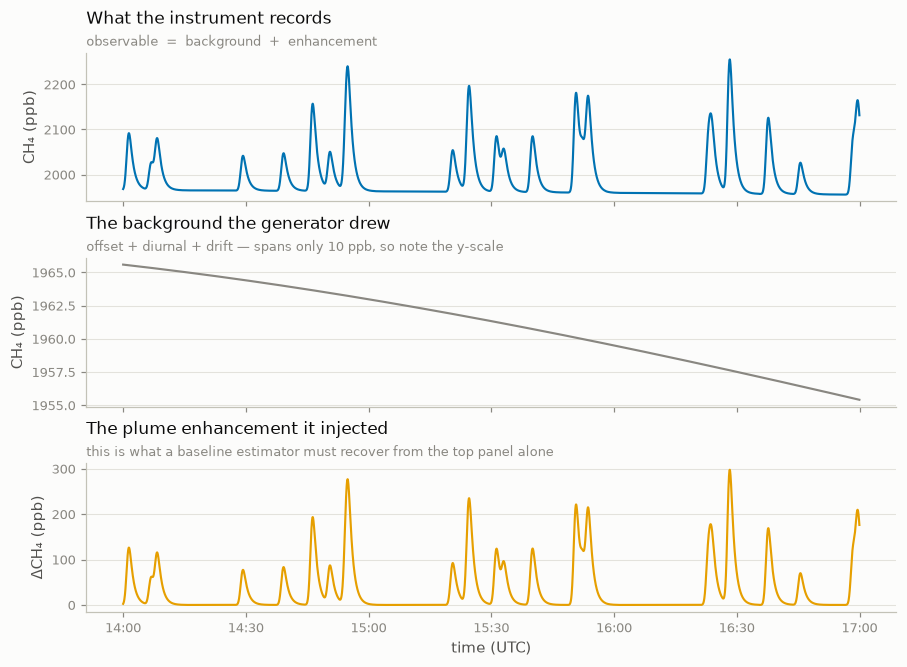

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9.5, 6.6), sharex=True, gridspec_kw={"hspace": 0.38})

axes[0].plot(t, stream["ch4"].values, color=C1)
finish(
    axes[0], "What the instrument records", "observable  =  background  +  enhancement", "CH₄ (ppb)"
)

bg = stream["truth_background_ch4"].values
axes[1].plot(t, bg, color=MUTED)
finish(
    axes[1],
    "The background the generator drew",
    f"offset + diurnal + drift — spans only {np.ptp(bg):.0f} ppb, so note the y-scale",
    "CH₄ (ppb)",
)

axes[2].plot(t, stream["truth_enhancement_ch4"].values, color=C2)
finish(
    axes[2],
    "The plume enhancement it injected",
    "this is what a baseline estimator must recover from the top panel alone",
    "ΔCH₄ (ppb)",
)
axes[2].set_xlabel("time (UTC)")
hhmm(axes[2])

residual = (
    stream["ch4"].values
    - stream["truth_background_ch4"].values
    - stream["truth_enhancement_ch4"].values
)
print(
    f"observable - (background + enhancement) : max |residual| = {np.abs(residual).max():.2e} ppb"
)
from_the_air = ds.atmosphere.value("ch4", stream["time"].values)
print(
    f"observable - the atmosphere at the same instants : max = "
    f"{np.abs(stream['ch4'].values - from_the_air).max():.2e} ppb"
)
plt.show()

Both differences printed above are exactly zero. This run declared no
measurement error, so the instrument's record *is* the atmosphere, sampled at the
instrument's timestamps — not approximately, but to the last bit, because the
generator computes an instrument's signal through the same code that answers
`ds.atmosphere.value`. Section 7 adds an error budget, and the difference becomes
that instrument's noise.

---
## 3. Plume shapes

A plume measured downwind is not symmetric. Turbulent dispersion stretches it:
concentration rises sharply as you enter and decays slowly as you leave. TSARA's
default shape is an **exponentially modified gaussian** (EMG) — a gaussian of
width σ convolved with an exponential of timescale τ — because τ is exactly the
knob for that tail.

τ is not cosmetic. A detector that exits a plume the moment the signal stops
rising will truncate every EMG tail, and a baseline that fits through the tail
will sit too high. Both failure modes are invisible if you only ever test on
symmetric bumps, which is the reason the generator can make asymmetric ones.

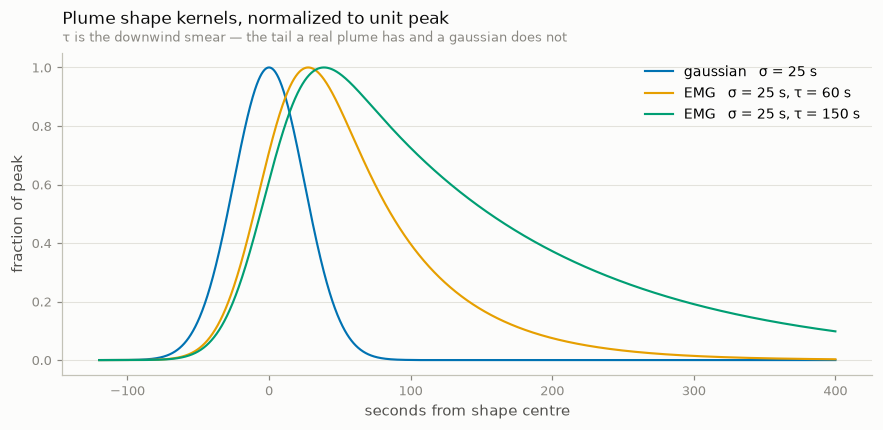

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
dt = np.linspace(-120, 400, 2000)

for shape, color, label in [
    (GaussianShape(kind="gaussian", sigma="25s"), C1, "gaussian   σ = 25 s"),
    (EMGShape(kind="emg", sigma="25s", tau="60s"), C2, "EMG   σ = 25 s, τ = 60 s"),
    (EMGShape(kind="emg", sigma="25s", tau="150s"), C3, "EMG   σ = 25 s, τ = 150 s"),
]:
    ax.plot(dt, build_kernel(shape).evaluate(dt), color=color, label=label)

finish(
    ax,
    "Plume shape kernels, normalized to unit peak",
    "τ is the downwind smear — the tail a real plume has and a gaussian does not",
    "fraction of peak",
    "seconds from shape centre",
    legend=True,
)
plt.show()

Two implementation notes worth knowing, both documented in METHODS.md §8.2:

- The EMG is evaluated through `scipy.special.erfcx` (the scaled complementary
  error function). The textbook form multiplies a huge exponential by a tiny
  complementary error function and evaluates to `inf * 0 = nan` far out in the
  tail. Below z ≈ −26 even `erfcx` overflows, and a closed-form asymptotic branch
  takes over.
- Each kernel carries a **finite support window** (4σ for a gaussian, 6τ for the
  EMG tail — 0.25 % of peak). Rendering only inside that window keeps generation
  O(events × window) instead of O(events × record), which is what lets a
  plume-dense multi-day record generate in seconds.

---
## 4. One physical world

Here is the single most important structural decision in the generator.

A plume is **one physical release**. If a well pad vents, the same gas reaches
the methane analyzer and the ethane analyzer — at the same moment, in the same
proportion. So the air is realized **once, for the whole campaign, before any
instrument exists**: every plume event, and every field's background. Every
instrument then samples that shared truth.

The alternative — drawing plumes per instrument, or per species — would produce
data that looks completely reasonable and is scientifically worthless: the
species would no longer covary, so any ratio fitted from it would be measuring
the random number generator. Every regression test built on such data would pass
while testing nothing.

Below: ethane enhancement against methane enhancement, in a world where the
declared ratio is **0.062 with zero spread**.

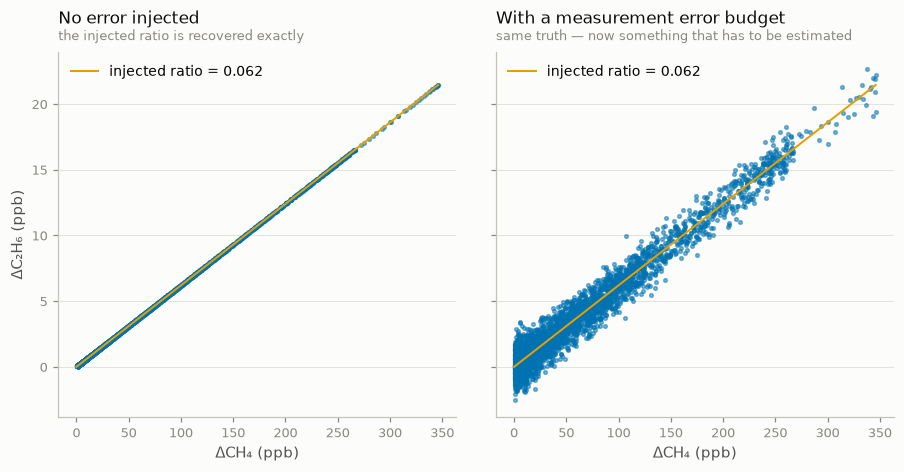

In [6]:
RATIO = 0.062


def ratio_config(seed, sigma_ch4=0.0, sigma_c2h6=0.0):
    """Build the same physical world every time; only the error budget changes."""

    def unc(sigma):
        return TrueUncertainty(random=TrueComponent(absolute=sigma)) if sigma else None

    return SyntheticConfig(
        name="ratio",
        start=START,
        duration="3h",
        seed=seed,
        platform=StationarySite(kind="stationary", latitude=40.0, longitude=-111.0),
        atmosphere=AtmosphereSpec(
            fields={
                "ch4": FieldSpec(
                    units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
                ),
                "c2h6": FieldSpec(
                    units="ppb", background=ParametricBackground(kind="parametric", offset=1.2)
                ),
            },
            sources={
                "pad": SourceSpec(
                    rate_per_hour=8.0,
                    reference_species="ch4",
                    shape=EMGShape(kind="emg", sigma="25s", tau="60s"),
                    amplitude=LognormalAmplitude(kind="lognormal", median=130.0, sigma_log=0.45),
                    ratios={"c2h6": RatioSpec(mean=RATIO, relative_spread=0.0)},
                )
            },
        ),
        instruments={
            "a": InstrumentSpec(
                native_rate="2s",
                measures={
                    "ch4": MeasurementSpec(uncertainty=unc(sigma_ch4)),
                    "c2h6": MeasurementSpec(uncertainty=unc(sigma_c2h6)),
                },
            )
        },
    )


s_clean = generate(ratio_config(21)).streams["a"]
s_noisy = generate(ratio_config(21, sigma_ch4=8.0, sigma_c2h6=0.9)).streams["a"]

fig, axes = plt.subplots(
    1, 2, figsize=(9.8, 4.3), sharex=True, sharey=True, gridspec_kw={"wspace": 0.10}
)
for ax, s, title, sub in [
    (axes[0], s_clean, "No error injected", "the injected ratio is recovered exactly"),
    (
        axes[1],
        s_noisy,
        "With a measurement error budget",
        "same truth — now something that has to be estimated",
    ),
]:
    x = s["truth_enhancement_ch4"].values
    y = s["c2h6"].values - s["truth_background_c2h6"].values
    inside = x > 1.0  # only inside plumes
    ax.plot(x[inside], y[inside], marker="o", markersize=2.4, linestyle="none", color=C1, alpha=0.5)
    xs = np.array([0.0, x.max()])
    ax.plot(xs, RATIO * xs, color=C2, linewidth=1.3, label=f"injected ratio = {RATIO}")
    finish(ax, title, sub, xlab="ΔCH₄ (ppb)", legend=True, loc="upper left")
axes[0].set_ylabel("ΔC₂H₆ (ppb)")
plt.show()

The left panel is a straight line through the origin with no scatter whatsoever
— the ratio is not approximately 0.062, it *is* 0.062 at every sample. That is
the invariant the test suite asserts, and it is what proves the shared-event
ordering is intact.

The right panel is the same physical world with an error budget added. This is
what Phase 7's regression estimators will be handed, and the left panel is the
answer they have to reproduce.

### Two analyzers, one atmosphere

The same idea holds across instruments, not just across species. Below, one
methane field — a background that wanders as a random walk, with plumes crossing
it — is measured by two analyzers on one inlet: a fast one that reads every 2 s
with 4 ppb of noise, and a slow one that reports noise-free one-minute means. The
thin dark line is the atmosphere itself, asked for its value every second. No
instrument measured that line; it is what both of them are sampling.

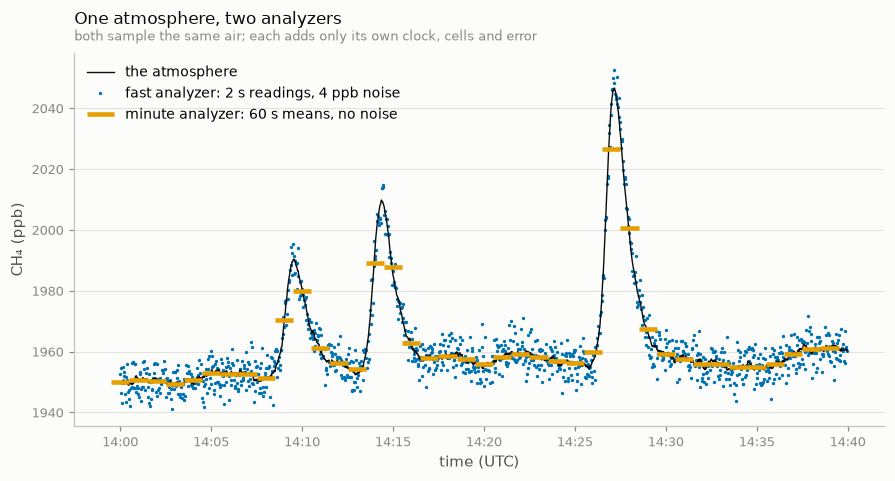

fast analyzer minus the atmosphere   : std 3.97 ppb  (declared: 4.00)
minute analyzer minus the atmosphere's minute means : max 0.0e+00 ppb
the background wandered by           : 14.1 ppb


In [7]:
shared = SyntheticConfig(
    name="one_atmosphere",
    start=START,
    duration="40min",
    seed=12,
    platform=StationarySite(kind="stationary", latitude=40.77, longitude=-111.89),
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb",
                background=ParametricBackground(
                    kind="parametric", offset=1950.0, random_walk_std=80.0
                ),
            )
        },
        sources={
            "pad": SourceSpec(
                rate_per_hour=6.0,
                reference_species="ch4",
                shape=EMGShape(kind="emg", sigma="20s", tau="45s"),
                amplitude=LognormalAmplitude(kind="lognormal", median=60.0, sigma_log=0.4),
            )
        },
    ),
    instruments={
        # Two instruments measuring the SAME field. Each adds only its own
        # clock, cells and error; the slow one names its record `ch4_minute`.
        "fast": InstrumentSpec(
            native_rate="2s",
            measures={
                "ch4": MeasurementSpec(
                    uncertainty=TrueUncertainty(random=TrueComponent(absolute=4.0))
                )
            },
        ),
        "minute": InstrumentSpec(
            native_rate="60s",
            support=TrueSupport(method="mean"),
            measures={"ch4": MeasurementSpec(name="ch4_minute")},
        ),
    },
)
d_shared = generate(shared)
air = d_shared.atmosphere
fast_s, minute_s = d_shared.streams["fast"], d_shared.streams["minute"]

every_second = pd.date_range(START, START + pd.Timedelta("40min"), freq="1s", inclusive="left")
edges = minute_s["time_bnds"].values

fig, ax = plt.subplots(figsize=(9.5, 4.4))
# Drawn over the readings, thin and dark, so the truth stays visible between plumes.
ax.plot(
    every_second,
    air.value("ch4", every_second),
    color=INK,
    lw=0.9,
    zorder=3,
    label="the atmosphere",
)
ax.plot(
    pd.DatetimeIndex(fast_s["time"].values),
    fast_s["ch4"].values,
    ".",
    ms=2.4,
    color=C1,
    label="fast analyzer: 2 s readings, 4 ppb noise",
)
ax.hlines(
    minute_s["ch4_minute"].values,
    edges[:, 0],
    edges[:, 1],
    color=C2,
    lw=3.0,
    zorder=4,
    label="minute analyzer: 60 s means, no noise",
)
hhmm(ax)
finish(
    ax,
    "One atmosphere, two analyzers",
    "both sample the same air; each adds only its own clock, cells and error",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
plt.show()

# The claims, measured rather than eyeballed.
own_noise = fast_s["ch4"].values - air.value("ch4", fast_s["time"].values)
cells = CellBounds(
    start_ns=edges[:, 0].astype("datetime64[ns]").astype(np.int64),
    stop_ns=edges[:, 1].astype("datetime64[ns]").astype(np.int64),
)
minute_gap = minute_s["ch4_minute"].values - air.mean_over("ch4", cells, subsamples=64)
print(f"fast analyzer minus the atmosphere   : std {own_noise.std():.2f} ppb  (declared: 4.00)")
print(
    f"minute analyzer minus the atmosphere's minute means : max {np.abs(minute_gap).max():.1e} ppb"
)
print(
    f"the background wandered by           : {np.ptp(air.background('ch4', every_second)):.1f} ppb"
)

The dots scatter around the dark line by exactly their own noise, and the bars
are exactly the atmosphere's mean over each minute — zero difference, because a
`mean` instrument averages the same truth the line draws. Both analyzers saw
the same wander and the same plumes. What differs is only what belongs to each:
the fast one's noise, the slow one's one-minute cells (see how the narrow plumes
come out diluted in the bars).

That was not always so. Until Phase 4.5 each instrument rendered its own copy of
each species, and a random-walk background was drawn separately for every copy:
two identical analyzers on one inlet disagreed by about as much as the background
itself varied, because they were measuring two different atmospheres.
`docs/METHODS.md` §8.1.1 has the before-and-after measurements.

---
## 5. Clocks

Real instruments do not share a clock and do not deliver perfect grids. TSARA's
architecture is built on that fact — it **synchronizes late**, keeping every
stream at its own native rate for baselines, detection and pairing — so the
generator has to produce data that is genuinely irregular, or that machinery
would never be tested.

Three separate departures from a perfect grid:

- **different native rates** across instruments, which is the multi-rate
  alignment problem itself;
- **timestamp jitter**, bounded by the schema at under half the nominal interval
  so the clock can never run backwards;
- **dropouts**, which *delete* samples rather than filling them with NaN —
  because that is what a logger that stops writing actually produces, and the
  resulting gaps are what rolling-window logic has to survive.

aeris  : 3,160 samples, 10 gaps above 1.5x nominal
picarro: 900 samples
gps    : 1,800 samples


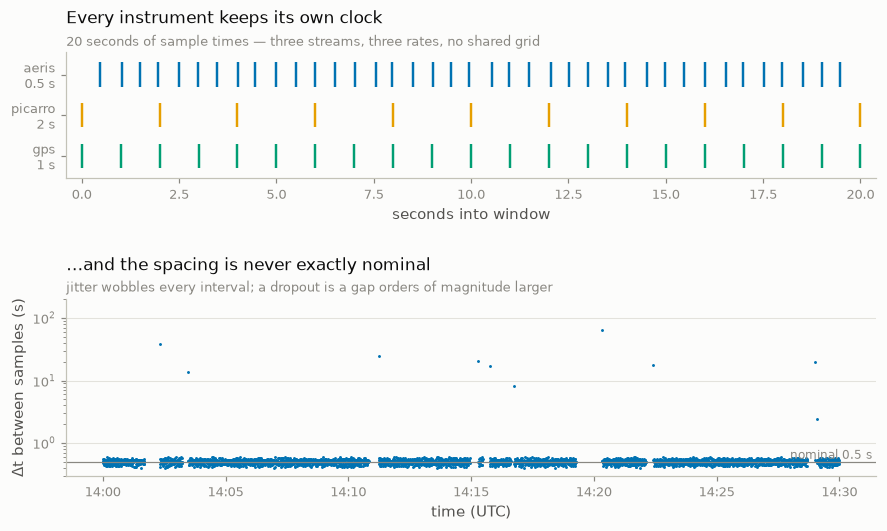

In [8]:
multi = SyntheticConfig(
    name="clocks",
    start=START,
    duration="30min",
    seed=3,
    platform=MobileTrack(
        kind="mobile",
        gps_rate="1s",
        start_latitude=40.77,
        start_longitude=-111.89,
        speed_m_s=13.0,
        pattern="circuit",
        radius_m=1200.0,
    ),
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
            ),
            "co2": FieldSpec(
                units="ppm", background=ParametricBackground(kind="parametric", offset=415.0)
            ),
        }
    ),
    instruments={
        "aeris": InstrumentSpec(
            native_rate="0.5s",
            timestamp_jitter="0.05s",
            dropouts={"rate_per_day": 400.0, "duration": "45s"},
            measures={"ch4": MeasurementSpec()},
        ),
        "picarro": InstrumentSpec(native_rate="2s", measures={"co2": MeasurementSpec()}),
    },
)
dm = generate(multi)

fig, axes = plt.subplots(
    2, 1, figsize=(9.5, 5.0), gridspec_kw={"height_ratios": [1, 1.4], "hspace": 0.8}
)

t0 = pd.Timestamp(dm.streams["picarro"]["time"].values[0])
for i, (name, color) in enumerate([("aeris", C1), ("picarro", C2), ("gps", C3)]):
    sec = (pd.DatetimeIndex(dm.streams[name]["time"].values) - t0).total_seconds()
    axes[0].eventplot(
        [sec[(sec >= 0) & (sec <= 20)]],
        lineoffsets=[2 - i],
        linelengths=[0.6],
        colors=[color],
        linewidths=1.6,
    )
axes[0].set_yticks([2, 1, 0])
axes[0].set_yticklabels(["aeris\n0.5 s", "picarro\n2 s", "gps\n1 s"], fontsize=8.5)
axes[0].set_xlim(-0.4, 20.4)
axes[0].set_ylim(-0.55, 2.55)
finish(
    axes[0],
    "Every instrument keeps its own clock",
    "20 seconds of sample times — three streams, three rates, no shared grid",
    xlab="seconds into window",
    grid_axis=None,
)

ta = pd.DatetimeIndex(dm.streams["aeris"]["time"].values)
dt_s = np.diff(ta.values).astype("timedelta64[ms]").astype(float) / 1000.0
axes[1].plot(ta[1:], dt_s, marker=".", markersize=1.8, linestyle="none", color=C1)
axes[1].axhline(0.5, color=MUTED, linewidth=0.8)
axes[1].set_yscale("log")
axes[1].set_ylim(0.3, 200)
hhmm(axes[1])
finish(
    axes[1],
    "…and the spacing is never exactly nominal",
    "jitter wobbles every interval; a dropout is a gap orders of magnitude larger",
    "Δt between samples (s)",
    "time (UTC)",
)
axes[1].annotate(
    "nominal 0.5 s",
    xy=(0.995, 0.5),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    fontsize=8,
    color=MUTED,
)

print(
    f"aeris  : {dm.streams['aeris'].sizes['time']:,} samples, "
    f"{(dt_s > 1.5 * 0.5).sum()} gaps above 1.5x nominal"
)
print(f"picarro: {dm.streams['picarro'].sizes['time']:,} samples")
print(f"gps    : {dm.streams['gps'].sizes['time']:,} samples")
plt.show()

Note the GPS is its own stream on its own clock. That is deliberate: position is
a smooth auxiliary field that *may* be interpolated onto gas timestamps, while
the gases themselves may **not** be. Putting GPS on the gas clock would make
that distinction untestable — the generator would have quietly solved the
problem Phase 4 exists to solve.

---
## 6. Backgrounds — where real data enters

Everything so far was invented from declared numbers. This is the one place real
measurements can be used, and it is worth being precise about how.

### The parametric background

Four terms you write down: a constant `offset`, a `diurnal_amplitude` cycle, a
linear `drift_per_day` measured from the campaign start, and a `random_walk_std`
wander. The last is the only one with no formula, so the generator draws it once
for the whole atmosphere, on nodes one second apart (`atmosphere.truth_resolution`),
and joins the nodes with straight lines — which keeps it a fixed function of time
that every instrument samples identically. All four declared, no data involved.

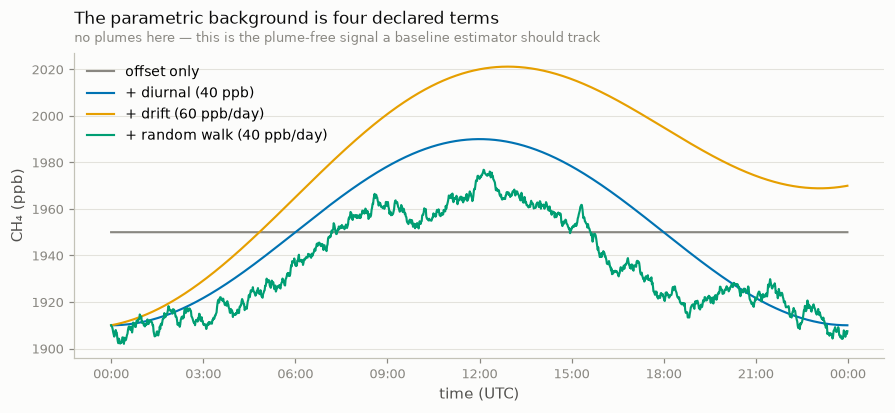

In [9]:
day = SyntheticConfig(
    name="bg",
    start=datetime(2026, 6, 15, 0, 0, tzinfo=UTC),
    duration="24h",
    seed=1,
    platform=StationarySite(kind="stationary", latitude=40.77, longitude=-111.89),
    atmosphere=AtmosphereSpec(
        fields={
            "flat": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
            ),
            "diurnal": FieldSpec(
                units="ppb",
                background=ParametricBackground(
                    kind="parametric", offset=1950.0, diurnal_amplitude=40.0
                ),
            ),
            "full": FieldSpec(
                units="ppb",
                background=ParametricBackground(
                    kind="parametric", offset=1950.0, diurnal_amplitude=40.0, drift_per_day=60.0
                ),
            ),
            "wander": FieldSpec(
                units="ppb",
                background=ParametricBackground(
                    kind="parametric",
                    offset=1950.0,
                    diurnal_amplitude=40.0,
                    drift_per_day=60.0,
                    random_walk_std=40.0,
                ),
            ),
        }
    ),
    instruments={
        "a": InstrumentSpec(
            native_rate="60s",
            measures={name: MeasurementSpec() for name in ("flat", "diurnal", "full", "wander")},
        )
    },
)
sd = generate(day).streams["a"]
td = pd.DatetimeIndex(sd["time"].values)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(td, sd["truth_background_flat"].values, color=MUTED, label="offset only")
ax.plot(td, sd["truth_background_diurnal"].values, color=C1, label="+ diurnal (40 ppb)")
ax.plot(td, sd["truth_background_full"].values, color=C2, label="+ drift (60 ppb/day)")
ax.plot(td, sd["truth_background_wander"].values, color=C3, label="+ random walk (40 ppb/day)")
hhmm(ax)
finish(
    ax,
    "The parametric background is four declared terms",
    "no plumes here — this is the plume-free signal a baseline estimator should track",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
plt.show()

### The bootstrap background — the real-data seam

A parametric background is smooth and well-behaved in a way real air is not. The
higher-realism option resamples contiguous blocks of **real, baseline-subtracted
fluctuation** from your own archive, preserving whatever short-range
autocorrelation, skew and instrument quirks the real record has — structure no
parametric model reproduces.

`profile_series()` does the measuring:

1. fit a rolling low-quantile background;
2. subtract it to get the residual;
3. characterize the residual — robust spread, plume-immune noise scale, lag-1
   autocorrelation;
4. cut it into contiguous, gap-free, **mean-centred** blocks for resampling.

The resampled blocks become part of the atmosphere, laid down at the real
record's **own sampling period**. An instrument sampling faster or slower than
that record therefore still sees the real correlation timescale, rather than a
copy stretched or squeezed to fit its own clock.

The config refers to the result **by name only**:

```yaml
atmosphere:
  fields:
    ch4:
      background:
        kind: bootstrap
        profile: picarro_ch4        # a key, not data
        base: {kind: parametric, offset: 1950.0}
```

and the profile object is handed to `generate()` at call time:

```python
profile = profile_series(real_series, name="picarro_ch4")
dataset = generate(config, profiles={"picarro_ch4": profile})
```

**Why the indirection.** If profiles were embedded in the config, the config
would stop being round-trippable YAML (you cannot losslessly serialize a
`(2000, 512)` float array into a readable text file), and every saved bundle's
`config.yaml` would carry thousands of real measured numbers from the archive
into git. Referencing by name keeps the config a small readable file and
guarantees **no real number can ever reach a committed file**. The cost is that
a bundle using a bootstrap background is not quite self-reproducing — you need
the mount to rebuild the profile. That trade is deliberate.

The code calls this **profiling**, never "calibration" — in this field
calibration means gas-standard referencing, and reusing the word here would be
actively confusing in a package that will eventually do both.

In [10]:
import os

from tsara.synthetic import profile_series

# A synthetic plume-dense record makes the same point real data would: once
# broad plumes leak through the profiling baseline, residual_sigma pulls well
# above noise_sigma. No real measurement is needed to demonstrate that, so
# the walkthrough never depends on one.
dense = SyntheticConfig(
    name="profiling_demo",
    start=START,
    duration="6h",
    seed=11,
    platform=StationarySite(kind="stationary", latitude=40.77, longitude=-111.89),
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
            )
        },
        sources={
            "pad": SourceSpec(
                rate_per_hour=15.0,
                reference_species="ch4",
                shape=EMGShape(kind="emg", sigma="30s", tau="90s"),
                amplitude=LognormalAmplitude(kind="lognormal", median=120.0, sigma_log=0.5),
                ratios={},
            )
        },
    ),
    instruments={
        "a": InstrumentSpec(
            native_rate="2s",
            measures={
                "ch4": MeasurementSpec(
                    uncertainty=TrueUncertainty(random=TrueComponent(absolute=0.7))
                )
            },
        )
    },
)
demo_stream = generate(dense).streams["a"]
demo_series = pd.Series(
    demo_stream["ch4"].values, index=pd.DatetimeIndex(demo_stream["time"].values)
)

demo_prof = profile_series(demo_series, name="synthetic_demo")
print(f"noise_sigma           : {demo_prof.noise_sigma:.3f}")
print(f"residual_sigma        : {demo_prof.residual_sigma:.3f}")
print(f"ratio                 : {demo_prof.residual_sigma / demo_prof.noise_sigma:.1f}")
print(f"lag-1 autocorrelation : {demo_prof.lag1_autocorr:.4f}")
print(f"blocks retained       : {demo_prof.residual_blocks.shape}")

# --- optional: point this at your own archive -------------------------------
# Gated on an environment variable so this notebook runs anywhere, and so no
# real measurement is ever embedded in a committed output -- whatever this
# prints when TSARA_REAL_DATA is set is never saved back into the notebook.
real_path = os.environ.get("TSARA_REAL_DATA")
if real_path:
    real_series = pd.read_parquet(real_path)["CH4_sync"].dropna()
    real_prof = profile_series(real_series, name="picarro_ch4")
    print()
    print("live-mount profile:", real_prof.summary())
else:
    print()
    print("TSARA_REAL_DATA not set -- skipping the live-mount comparison.")

noise_sigma           : 1.270
residual_sigma        : 54.844
ratio                 : 43.2
lag-1 autocorrelation : 0.9996
blocks retained       : (21, 512)

TSARA_REAL_DATA not set -- skipping the live-mount comparison.


The ratio printed above answers a real question: is this record noisy, or just
full of plume structure a simple quantile baseline could not fully remove? A
`residual_sigma` comfortably above `noise_sigma` is the signature of the
latter — broad enhancements leak through a rolling low-quantile fit while
`diff_mad`, working on first differences, stays immune to them by construction
(METHODS.md §2.5). Any real ambient trace-gas archive with no plume-free
stretches shows the same pattern, often by an order of magnitude or more.

`lag1_autocorr` inherits the same caveat regardless of what generated the
record: it describes the **bootstrap substrate** (what block resampling would
reproduce), not an instrument's noise decorrelation timescale. And it is
numerically fragile wherever it sits close to 1. Since τ = −Δt / ln ρ,

$$\frac{d\tau/\tau}{d\rho/\rho} \;=\; \frac{-1}{\rho \ln \rho}$$

which is already ≈ 334 at ρ₁ = 0.997 — a value plume-dense ambient records can
plausibly reach. At Δt = 2 s that is τ = 666 s for ρ₁ = 0.997 versus τ = 499 s
for ρ₁ = 0.996 — a one-part-in-a-thousand shift in ρ₁ moves the answer by a
quarter. Treat this field as an order-of-magnitude indicator on strongly
autocorrelated records, never a calibrated timescale. Both caveats are in
METHODS.md §8.3/§8.4.

---
## 7. Error injection

TSARA's uncertainty model has two components, and the distinction between them
is not bookkeeping — it changes what averaging can buy you.

- **Random** — uncorrelated point to point. Averaging N samples shrinks it by
  √N.
- **Systematic** — correlated across the record. Averaging does **nothing** to
  it, ever.

In the generator the systematic component is a genuine **rank-1 draw**: two
standard normals drawn once per measurement per run — an instrument's calibration
error belongs to that instrument — applied to every sample. That
construction is what makes "does not average down" literally true rather than
merely asserted — and testable.

To see it you have to average within a realization and then look *across*
realizations. Below: 400 independent runs, averaging the first N points of each,
plotting the spread of the answer.

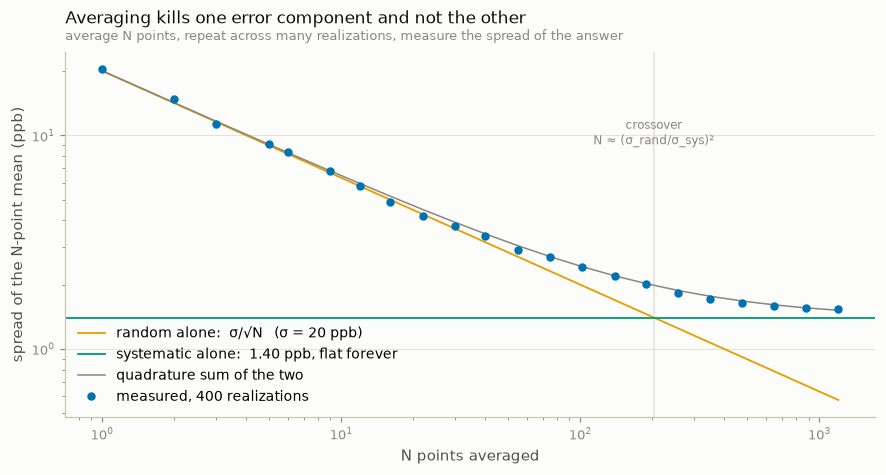

In [11]:
SIG_RAND, SIG_SYS_REL, LEVEL = 20.0, 0.00072, 1950.0
SIG_SYS = SIG_SYS_REL * LEVEL


def one_run(seed):
    """Return a flat, plume-free record whose only content is the error budget."""
    cfg = SyntheticConfig(
        name="err",
        start=START,
        duration="20min",
        seed=seed,
        platform=StationarySite(kind="stationary", latitude=40.0, longitude=-111.0),
        atmosphere=AtmosphereSpec(
            fields={
                "ch4": FieldSpec(
                    units="ppb", background=ParametricBackground(kind="parametric", offset=LEVEL)
                )
            }
        ),
        instruments={
            "a": InstrumentSpec(
                native_rate="1s",
                measures={
                    "ch4": MeasurementSpec(
                        uncertainty=TrueUncertainty(
                            random=TrueComponent(absolute=SIG_RAND),
                            systematic=TrueComponent(relative=SIG_SYS_REL),
                        )
                    )
                },
            )
        },
    )
    s = generate(cfg).streams["a"]
    return s["ch4"].values - s["truth_background_ch4"].values


M = 400
errors = np.array([one_run(1000 + i) for i in range(M)])
Ns = np.unique(np.round(np.logspace(0, np.log10(errors.shape[1]), 24)).astype(int))
spread = np.array([errors[:, :n].mean(axis=1).std(ddof=1) for n in Ns])
combined = np.sqrt((SIG_RAND / np.sqrt(Ns)) ** 2 + SIG_SYS**2)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(
    Ns,
    SIG_RAND / np.sqrt(Ns),
    color=C2,
    linewidth=1.2,
    label=f"random alone:  σ/√N   (σ = {SIG_RAND:.0f} ppb)",
)
ax.axhline(
    SIG_SYS, color=C3, linewidth=1.2, label=f"systematic alone:  {SIG_SYS:.2f} ppb, flat forever"
)
ax.plot(Ns, combined, color=MUTED, linewidth=1.0, label="quadrature sum of the two")
ax.plot(
    Ns,
    spread,
    marker="o",
    markersize=4.5,
    linestyle="none",
    color=C1,
    label=f"measured, {M} realizations",
)
ax.axvline((SIG_RAND / SIG_SYS) ** 2, color=GRID, linewidth=1.0, zorder=0)
ax.annotate(
    "crossover\nN ≈ (σ_rand/σ_sys)²",
    xy=((SIG_RAND / SIG_SYS) ** 2, 12),
    fontsize=8,
    color=MUTED,
    ha="center",
    va="top",
)
ax.set_xscale("log")
ax.set_yscale("log")
finish(
    ax,
    "Averaging kills one error component and not the other",
    "average N points, repeat across many realizations, measure the spread of the answer",
    "spread of the N-point mean (ppb)",
    "N points averaged",
    legend=True,
    loc="lower left",
)
plt.show()

The measured points sit on the quadrature sum across four decades. Past the
crossover at N ≈ 200, averaging harder buys nothing at all — the answer stops
improving and sits on the systematic floor forever.

This is why the manifest schema carries the two components separately, why
binning propagates them by different algebra (inverse-variance for random, a
weighted mean of sigmas for systematic — which is exact for fully correlated
errors), and why a combined uncertainty that assumed everything was i.i.d. would
report a confidence interval far tighter than the truth.

A measurement may also declare a `report_as` column — an instrument publishing its
own per-point uncertainty estimate, EM27-style — and `report_bias`, which lets
that published number deliberately *understate* the truth. That is how we build
data for testing whether the pipeline notices when an instrument is optimistic
about itself.

---
## 8. The answer key

The catalog: one row per (event, measured variable) — two instruments measuring
methane would each get a row — recording start, peak and end times,
the true amplitude, the true baseline underneath the peak, the realized ratio,
and the platform position.

It also records **nesting**. A sharp thermogenic blip riding on top of a broad
landfill plume is two events with a parent–child link, not one event and not
two independent ones. Phase 6 has to reproduce that structure, so the generator
has to be able to create it.

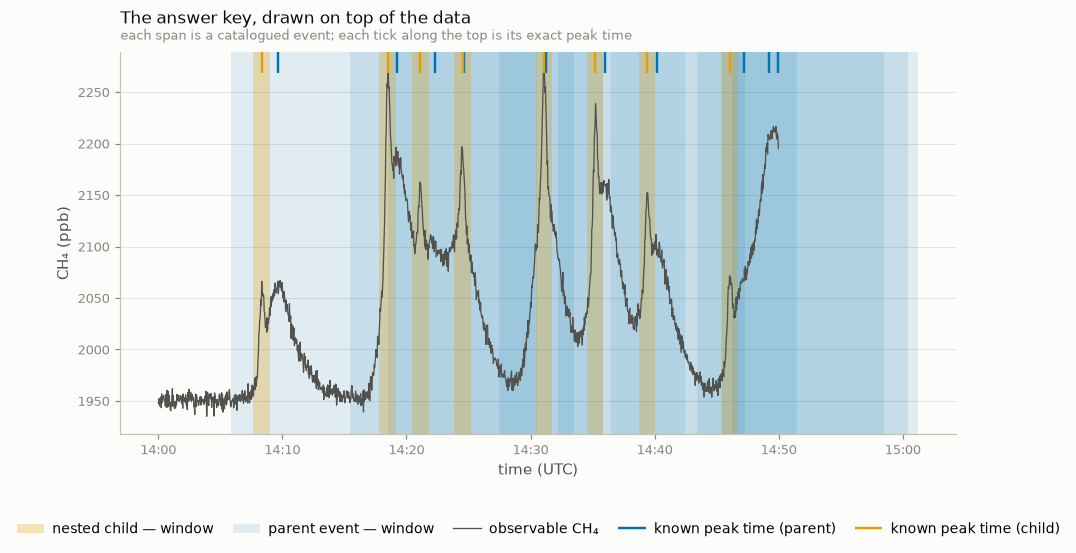

18 catalog rows, 8 of them nested children


,event_id,parent_event_id,peak_time,true_amplitude,sampled_peak_amplitude,true_baseline_at_peak
0,landfill_00000_child,landfill_00000,2026-06-15 14:08:20.083375276,66.394330,66.392022,1950.0
1,landfill_00000,NaN,2026-06-15 14:09:38.884382285,110.657217,110.646316,1950.0
2,landfill_00001,NaN,2026-06-15 14:19:14.984002957,235.224959,235.196260,1950.0
3,landfill_00001_child,landfill_00001,2026-06-15 14:18:29.197734998,141.134976,140.681513,1950.0
4,landfill_00002_child,landfill_00002,2026-06-15 14:21:06.628236399,61.472952,61.351761,1950.0
5,landfill_00002,NaN,2026-06-15 14:22:17.295458188,102.454920,102.448537,1950.0
6,landfill_00003,NaN,2026-06-15 14:24:37.267196517,124.132482,124.124117,1950.0
7,landfill_00003_child,landfill_00003,2026-06-15 14:24:30.980206325,74.479489,74.122546,1950.0


In [12]:
nested = SyntheticConfig(
    name="answer_key",
    start=START,
    duration="50min",
    seed=4,
    platform=StationarySite(kind="stationary", latitude=40.77, longitude=-111.89),
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
            )
        },
        sources={
            "landfill": SourceSpec(
                rate_per_hour=9.0,
                reference_species="ch4",
                shape=EMGShape(kind="emg", sigma="45s", tau="90s"),
                amplitude=LognormalAmplitude(kind="lognormal", median=140.0, sigma_log=0.35),
                ratios={},
                nested=NestedSpec(
                    probability=0.7,
                    shape=GaussianShape(kind="gaussian", sigma="10s"),
                    amplitude_factor=0.6,
                ),
            )
        },
    ),
    instruments={
        "a": InstrumentSpec(
            native_rate="2s",
            measures={
                "ch4": MeasurementSpec(
                    uncertainty=TrueUncertainty(random=TrueComponent(absolute=5.0))
                )
            },
        )
    },
)
dn = generate(nested)
sn = dn.streams["a"]
tn = pd.DatetimeIndex(sn["time"].values)

fig, ax = plt.subplots(figsize=(9.8, 4.5))
seen = {"p": False, "c": False}
for ev in dn.ground_truth.events:
    child = ev.parent_event_id is not None
    key = "c" if child else "p"
    ax.axvspan(
        ev.start_time,
        ev.end_time,
        color=C2 if child else C1,
        alpha=0.28 if child else 0.11,
        linewidth=0,
        zorder=2 if child else 1,
        label=(
            ("nested child — window" if child else "parent event — window")
            if not seen[key]
            else None
        ),
    )
    seen[key] = True

ax.plot(tn, sn["ch4"].values, color=INK2, linewidth=0.85, zorder=3, label="observable CH₄")

# Peak times as a rug along the top. Deliberately NOT drawn at
# baseline + true_amplitude: for a nested child that is the child's OWN
# contribution, which rides on top of its parent's, so a marker at that height
# would misstate what the field means.
ylo, yhi = ax.get_ylim()
for evs, color, lab in [
    (
        [e for e in dn.ground_truth.events if e.parent_event_id is None],
        C1,
        "known peak time (parent)",
    ),
    (
        [e for e in dn.ground_truth.events if e.parent_event_id is not None],
        C2,
        "known peak time (child)",
    ),
]:
    ax.vlines(
        [e.peak_time for e in evs],
        yhi - (yhi - ylo) * 0.055,
        yhi,
        color=color,
        linewidth=1.6,
        zorder=5,
        label=lab,
    )
ax.set_ylim(ylo, yhi)
hhmm(ax)
finish(
    ax,
    "The answer key, drawn on top of the data",
    "each span is a catalogued event; each tick along the top is its exact peak time",
    "CH₄ (ppb)",
    "time (UTC)",
)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=5, columnspacing=1.4, handletextpad=0.6
)
plt.show()

frame = dn.ground_truth.to_frame()
print(
    f"{len(frame)} catalog rows, {frame['parent_event_id'].notna().sum()} of them nested children"
)
frame[
    [
        "event_id",
        "parent_event_id",
        "peak_time",
        "true_amplitude",
        "sampled_peak_amplitude",
        "true_baseline_at_peak",
    ]
].head(8)

The heavy overlap of shaded spans is not a drawing artifact — at 9 events/hour
with a 90 s tail the plumes genuinely overlap, which is the realistic
near-source condition and precisely the case where naive baselines and
signal-MAD noise estimates both fail.

Two columns in that table answer different questions, and the distinction
matters when scoring a detector:

- **`true_amplitude`** — what the *source* did: the continuous peak of the
  injected shape.
- **`sampled_peak_amplitude`** — the largest value the instrument could possibly
  have seen, given where its samples happened to fall. It is `NaN` when an event
  landed entirely inside a dropout.

A detector cannot be faulted for missing the difference between them, and it
certainly cannot be faulted for missing an event that occurred while the
instrument was down. Storing both is what makes that a measurable distinction
rather than an argument.

---
## 9. Space

For a mobile platform the GPS becomes its own stream, and every catalog event
gets the platform position **at its peak**.

That is a deliberate and slightly uncomfortable choice: it records where the
*encounter* happened, not where the source is. But that is exactly what a real
mobile catalog records — a drive-by localizes the plume you drove through, and
recovering the source location from it needs a dispersion model the generator
does not have. Phase 8 clusters encounters into "source complexes"; inferring
true source positions is explicitly out of scope for v1.

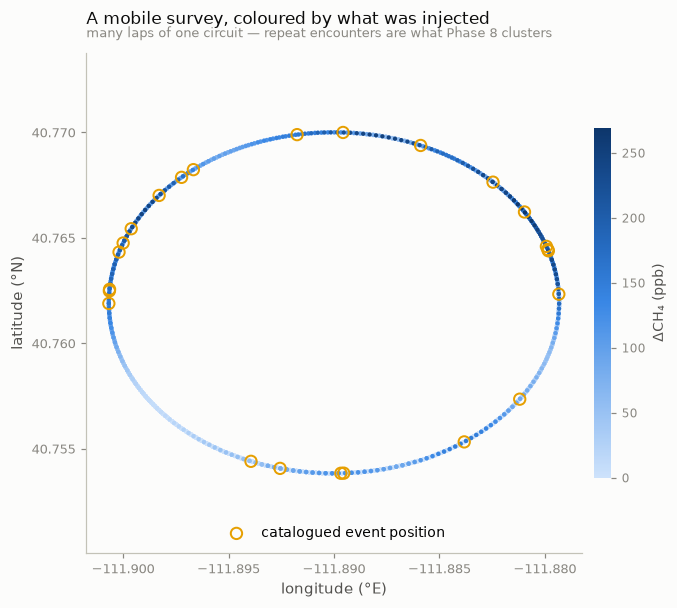

In [13]:
mob = SyntheticConfig(
    name="mobile",
    start=START,
    duration="2h",
    seed=5,
    platform=MobileTrack(
        kind="mobile",
        gps_rate="1s",
        start_latitude=40.77,
        start_longitude=-111.89,
        speed_m_s=13.0,
        pattern="circuit",
        radius_m=900.0,
    ),
    atmosphere=AtmosphereSpec(
        fields={
            "ch4": FieldSpec(
                units="ppb", background=ParametricBackground(kind="parametric", offset=1950.0)
            )
        },
        sources={
            "pad": SourceSpec(
                rate_per_hour=12.0,
                reference_species="ch4",
                shape=GaussianShape(kind="gaussian", sigma="20s"),
                amplitude=LognormalAmplitude(kind="lognormal", median=150.0, sigma_log=0.5),
                ratios={},
            )
        },
    ),
    instruments={"a": InstrumentSpec(native_rate="2s", measures={"ch4": MeasurementSpec()})},
)
dmob = generate(mob)
sm = dmob.streams["a"]
enh = sm["truth_enhancement_ch4"].values
order = np.argsort(enh)  # strong enhancements drawn last, never hidden

fig, ax = plt.subplots(figsize=(7.0, 5.9))
ax.plot(sm["longitude"].values, sm["latitude"].values, color=GRID, linewidth=0.8, zorder=1)
sc = ax.scatter(
    sm["longitude"].values[order],
    sm["latitude"].values[order],
    c=enh[order],
    s=8,
    cmap=BLUES,
    zorder=2,
    linewidths=0,
)
ax.scatter(
    [e.longitude for e in dmob.ground_truth.events],
    [e.latitude for e in dmob.ground_truth.events],
    s=55,
    facecolors="none",
    edgecolors=C2,
    linewidths=1.3,
    zorder=3,
    label="catalogued event position",
)
cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("ΔCH₄ (ppb)", fontsize=9)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, color=MUTED, labelcolor=MUTED)
for axis in (ax.xaxis, ax.yaxis):
    f = ScalarFormatter(useOffset=False)
    f.set_scientific(False)
    axis.set_major_formatter(f)
ax.set_aspect("equal", adjustable="datalim")
finish(
    ax,
    "A mobile survey, coloured by what was injected",
    "many laps of one circuit — repeat encounters are what Phase 8 clusters",
    "latitude (°N)",
    "longitude (°E)",
    legend=True,
    grid_axis=None,
    loc="lower center",
)
plt.show()

---
## 10. Persistence

A generated dataset saves as a **TSARA bundle** — a directory, not a single
file, and the layout every later phase extends rather than replaces:

```
<bundle>/
    bundle.json           contents + format version
    config.yaml           the exact config that produced it
    ground_truth.parquet  the answer key
    streams/
        <instrument>.nc   native-rate per-instrument Datasets
```

netCDF4 for streams because it is the atmospheric-community standard and xarray
round-trips it losslessly, including attrs and coordinates. Parquet for the
catalog because it is the format the Phase 6 `PlumeCatalog` will use — so ground
truth and detections end up directly comparable on disk with no conversion
layer.

Every stage product gains save/load **in the phase that introduces it**, so
intermediates are inspectable in a notebook, a long HPC run can resume after a
crash, and a dataset can be handed to a collaborator as one directory.

In [14]:
import json
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    bundle = ds.save(Path(tmp) / "walkthrough_bundle")

    print("on disk:")
    for p in sorted(bundle.rglob("*")):
        if p.is_file():
            print(f"   {p.relative_to(bundle).as_posix():<24} {p.stat().st_size / 1024:8.1f} KB")

    print()
    print("bundle.json:")
    print(json.dumps(json.loads((bundle / "bundle.json").read_text()), indent=2))

    # Round trip, and check it came back identical.
    from tsara.synthetic import load_bundle

    back = load_bundle(bundle)
    same_values = np.array_equal(
        back.streams["analyzer"]["ch4"].values, ds.streams["analyzer"]["ch4"].values
    )
    same_config = back.config == ds.config
    print()
    print(f"observable identical after round trip : {same_values}")
    print(f"config identical after round trip     : {same_config}")
    print(f"catalog rows preserved                : {len(back.ground_truth)}")
    same_air = np.array_equal(back.atmosphere.value("ch4", t), ds.atmosphere.value("ch4", t))
    print(f"atmosphere rebuilt from the config    : {same_air}")

on disk:
   bundle.json                   0.2 KB
   config.yaml                   1.5 KB
   ground_truth.parquet         11.6 KB
   streams/analyzer.nc         401.8 KB

bundle.json:
{
  "bundle_format_version": 3,
  "tsara_version": "0.1.0",
  "stage": "synthetic",
  "config_name": "walkthrough_clean",
  "streams": [
    "analyzer"
  ],
  "n_ground_truth_rows": 50
}

observable identical after round trip : True
config identical after round trip     : True
catalog rows preserved                : 50
atmosphere rebuilt from the config    : True


Note the function is `load_bundle`, not `load_synthetic`. That name belongs to
`tsara.config.loader.load_synthetic`, which reads a *config* — the YAML
description of a dataset to build — while this one reads the built *dataset*.
Both take a path and return something plausible-looking, so sharing a name meant
a notebook line's meaning depended on which import happened to be in scope. The
collision was found and removed during the Phase 2 review.

The atmosphere has no file of its own, and needs none. The generator draws it
before anything else, so replaying those draws from the saved config and seed
rebuilds it exactly — the last line above. (A bootstrap background is the one
exception: its real-data profile is never saved, so it must be passed to
`load_bundle` again.)

Every stream also self-describes in its attrs:

In [15]:
for key, value in ds.streams["analyzer"].attrs.items():
    print(f"  {key:24} {value}")

  tsara_version            0.1.0
  tsara_stage              synthetic
  synthetic_config_name    walkthrough_clean
  synthetic_seed           7
  instrument               analyzer
  native_rate              2s
  platform_kind            stationary
  tsara_support_label      mid
  tsara_cell_coverage      1.0
  tsara_support_label_provenance declared
  tsara_support_width_provenance declared
  tsara_support_method_provenance declared
  tsara_nominal_cell_width_s 2.0
  description              SYNTHETIC DATA generated by tsara.synthetic — not a measurement. Variables prefixed 'truth_' are the answer key and must not be consumed by analysis code.


`tsara_stage: synthetic` and that description are not decoration. A synthetic
file mistaken for a measurement is a scientific hazard, so the file says what it
is, in a place that survives being copied to somebody else's directory.

---
## 11. The ledger — what is real, and what is invented

| | Where it comes from |
|---|---|
| The atmosphere | **invented** — realized once from the declared fields and sources; every instrument samples it |
| Plume timing | **invented** — Poisson arrivals at a declared rate |
| Plume shape | **invented** — gaussian or EMG with declared σ, τ |
| Plume amplitude | **invented** — lognormal or uniform, declared |
| Inter-species ratios | **invented** — declared mean and spread. *This is the answer key.* |
| Nesting structure | **invented** — declared probability and amplitude factor |
| Sampling rates, jitter, dropouts | **invented** — declared |
| Platform track | **invented** — a circuit or random walk |
| Parametric background | **invented** — declared offset, diurnal, drift |
| Error budget | **invented** — declared random and systematic components |
| **Bootstrap background fluctuations** (opt-in) | **optional, real** — resampled blocks from a profile you build; not used above, and never committed |
| **Profile statistics** (noise σ, ρ₁) shown above | **synthetic** — measured from the plume-dense demo record, not from any archive |

Real data can enter at exactly one seam — profiling your own archive to build a
bootstrap background — and it would contribute *texture*, never truth: no plume,
no ratio, no error component is ever taken from a measurement, because every one
of those is something the pipeline is supposed to estimate.

This walkthrough never exercises that seam with real data. The profiling demo
above runs on a synthetic plume-dense record instead, which is enough to show
what `profile_series()` measures and why `residual_sigma / noise_sigma` and
`lag1_autocorr` mean what §8.3/§8.4 say they mean, with zero dependence on any
archive. The optional cell above will profile your own data live if
`TSARA_REAL_DATA` is set, but nothing it prints is ever saved into this notebook.

### What is deliberately not taken

- **No real numbers in any committed file.** Profiles are referenced by name and
  injected at call time.
- **A profiled ρ₁ is not used as a noise timescale.** It describes the
  bootstrap substrate, and is numerically ill-conditioned near ρ₁ = 1
  (METHODS.md §8.4).
- **No plume-free "clean" stretch is assumed to exist.** There isn't one in the
  archive, which is why injected truth is the only arbiter.

### Known limitations

- **Plume timing is not derived from track geometry.** There is no dispersion
  model placing sources in space and computing when the vehicle drives through
  them. Event coordinates are the platform position at the peak.
- **Systematic error is drawn independently per measurement.** So the generator
  cannot yet produce correlated x–y errors between species — the case behind the
  open question about York's per-point correlation term `r_i`. If Phase 7 adopts
  `r_i ≠ 0`, this generator change lands first.
- **A record never opens part-way through a plume** whose peak already passed,
  since centres are drawn inside the record. Real records routinely do. Deferred
  until Phase 5/6 shows whether edge behaviour needs it.

---

### What this is for

Everything after Phase 2 is developed against data generated here, before real
files are even readable. Phase 5's baselines are scored against
`truth_background_*`. Phase 6's detection is scored against the catalog. Phase
7's regressions are scored against `true_ratio_to_reference`, and their reported
confidence intervals are checked for whether they actually contain the truth at
their nominal rate — a question you can only ask when you know the truth.